# Victorian Fire History — Analysis & Visualization
**Project:** FireFusion | AI Modelling Stream  
**Purpose:** Extract, validate, preprocess and explore Victorian fire event data (2019–2023)  
**Sections:**
1. Config & Imports
2. Data Extraction (WFS)
3. Preprocessing
4. Exploratory Data Analysis

## 1. Config & Imports

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# ── Constants ──────────────────────────────────────────────────────────────
WFS_BASE    = "https://opendata.maps.vic.gov.au/geoserver/wfs"
LAYER       = "open-data-platform:fire_history"
YEARS       = ["2019", "2020", "2021", "2022", "2023"]
PAGE_SIZE   = 2000
RAW_FILE    = "../../src/data/fire_history_2019_2023.geojson"

# Model input features to retain from fire history
FIRE_FEATURES = ["season", "start_date", "area_ha", "fire_cover", "district_id", "geometry"]

# Plot colours
C_BUSHFIRE = "#D85A30"
C_BURN     = "#FAC775"

print("Config loaded.")

Config loaded.


## 2. Data Extraction (WFS)
Fetches paginated fire history records from the DataVic WFS endpoint.
Skips download if file already exists locally.

In [2]:
import os

def fetch_year(year: str, page_size: int = PAGE_SIZE) -> gpd.GeoDataFrame:
    """Fetch all fire history records for a given season via paginated WFS."""
    frames, start = [], 0
    while True:
        url = (
            f"{WFS_BASE}?SERVICE=WFS&VERSION=2.0.0&REQUEST=GetFeature"
            f"&TYPENAMES={LAYER}&outputFormat=application/json"
            f"&CQL_FILTER=season='{year}'"
            f"&count={page_size}&startIndex={start}"
        )
        page = gpd.read_file(url)
        if page.empty:
            break
        frames.append(page)
        print(f"  {year} | offset {start:>6} | {len(page)} rows fetched")
        if len(page) < page_size:
            break
        start += page_size
    return gpd.GeoDataFrame(pd.concat(frames, ignore_index=True)) if frames else gpd.GeoDataFrame()


if os.path.exists(RAW_FILE):
    print(f"'{RAW_FILE}' already exists — loading from disk.")
    combined = gpd.read_file(RAW_FILE)
else:
    print("Downloading from WFS...")
    combined = gpd.GeoDataFrame(
        pd.concat([fetch_year(y) for y in YEARS], ignore_index=True)
    )
    combined.to_file(RAW_FILE, driver="GeoJSON")
    print(f"Saved → {RAW_FILE}")

print(f"\nTotal records: {len(combined):,}")
print(f"Columns: {combined.columns.tolist()}")

'../../src/data/fire_history_2019_2023.geojson' already exists — loading from disk.

Total records: 98,213
Columns: ['id', 'firetype', 'season', 'fire_no', 'name', 'start_date', 'start_date_int', 'treatment_type', 'fire_severity', 'fire_cover', 'firekey', 'create_date', 'update_date', 'area_ha', 'method', 'method_comments', 'accuracy', 'dse_id', 'cfa_id', 'district_id', 'uc_2_date', 'cause', 'lead_agency', 'region', 'globalid', 'geometry']


## 3. Preprocessing
Type casting, filtering, log-normalisation and centroid extraction.

In [3]:
# ── Type casting ───────────────────────────────────────────────────────────
combined["season"]     = combined["season"].astype(str)
combined["area_ha"]    = pd.to_numeric(combined["area_ha"], errors="coerce")
combined["start_date"] = pd.to_datetime(combined["start_date"], utc=True, errors="coerce")

# ── Filter to bushfires only ───────────────────────────────────────────────
bushfires = combined[combined["firetype"] == "Bushfire"].copy()
bushfires = bushfires[bushfires["area_ha"] > 0].copy()   # drop zero/null area

In [4]:
# ── Log-normalise area for model input ────────────────────────────────────
bushfires["area_ha_log"] = np.log1p(bushfires["area_ha"])

# ── Accurate centroid: project → centroid → back to WGS84 ─────────────────
centroids_wgs = (
    bushfires.to_crs(epsg=7855)     # GDA2020 / MGA zone 55 (metres, Victoria)
             .geometry
             .centroid
             .pipe(lambda s: gpd.GeoSeries(s, crs="EPSG:7855"))
             .to_crs(epsg=4326)
)
bushfires = bushfires.to_crs(epsg=4326)
bushfires["lon"]      = centroids_wgs.x
bushfires["lat"]      = centroids_wgs.y
bushfires["date_str"] = bushfires["start_date"].dt.strftime("%Y-%m-%d")

print(f"Bushfire records (area > 0): {len(bushfires):,}")
print(bushfires[FIRE_FEATURES + ["lon", "lat", "date_str", "area_ha_log"]].head(5))

Bushfire records (area > 0): 68,738
    season                start_date     area_ha fire_cover                         district_id  \
4     2019 2019-01-29 00:00:00+00:00    2.065290     90-100                 Gippsland - Latrobe   
5     2019 2019-03-01 00:00:00+00:00  318.069812     90-100                 Gippsland - Latrobe   
6     2019 2018-11-18 00:00:00+00:00   59.677880     90-100          Barwon South West - Otways   
7     2019 2019-02-04 00:00:00+00:00    1.493813    UNKNOWN  Barwon South West - Far South West   
661   2019 2019-02-01 00:00:00+00:00  269.943595     90-100                 Gippsland - Latrobe   

                                              geometry         lon        lat    date_str  area_ha_log  
4    MULTIPOLYGON (((146.37188 -38.8613, 146.37185 ...  146.373019 -38.861292  2019-01-29     1.120142  
5    MULTIPOLYGON (((146.32923 -38.9898, 146.32932 ...  146.315309 -38.996923  2019-03-01     5.765410  
6    MULTIPOLYGON (((143.31982 -38.59242, 143.32 -3...

## 4. Exploratory Data Analysis

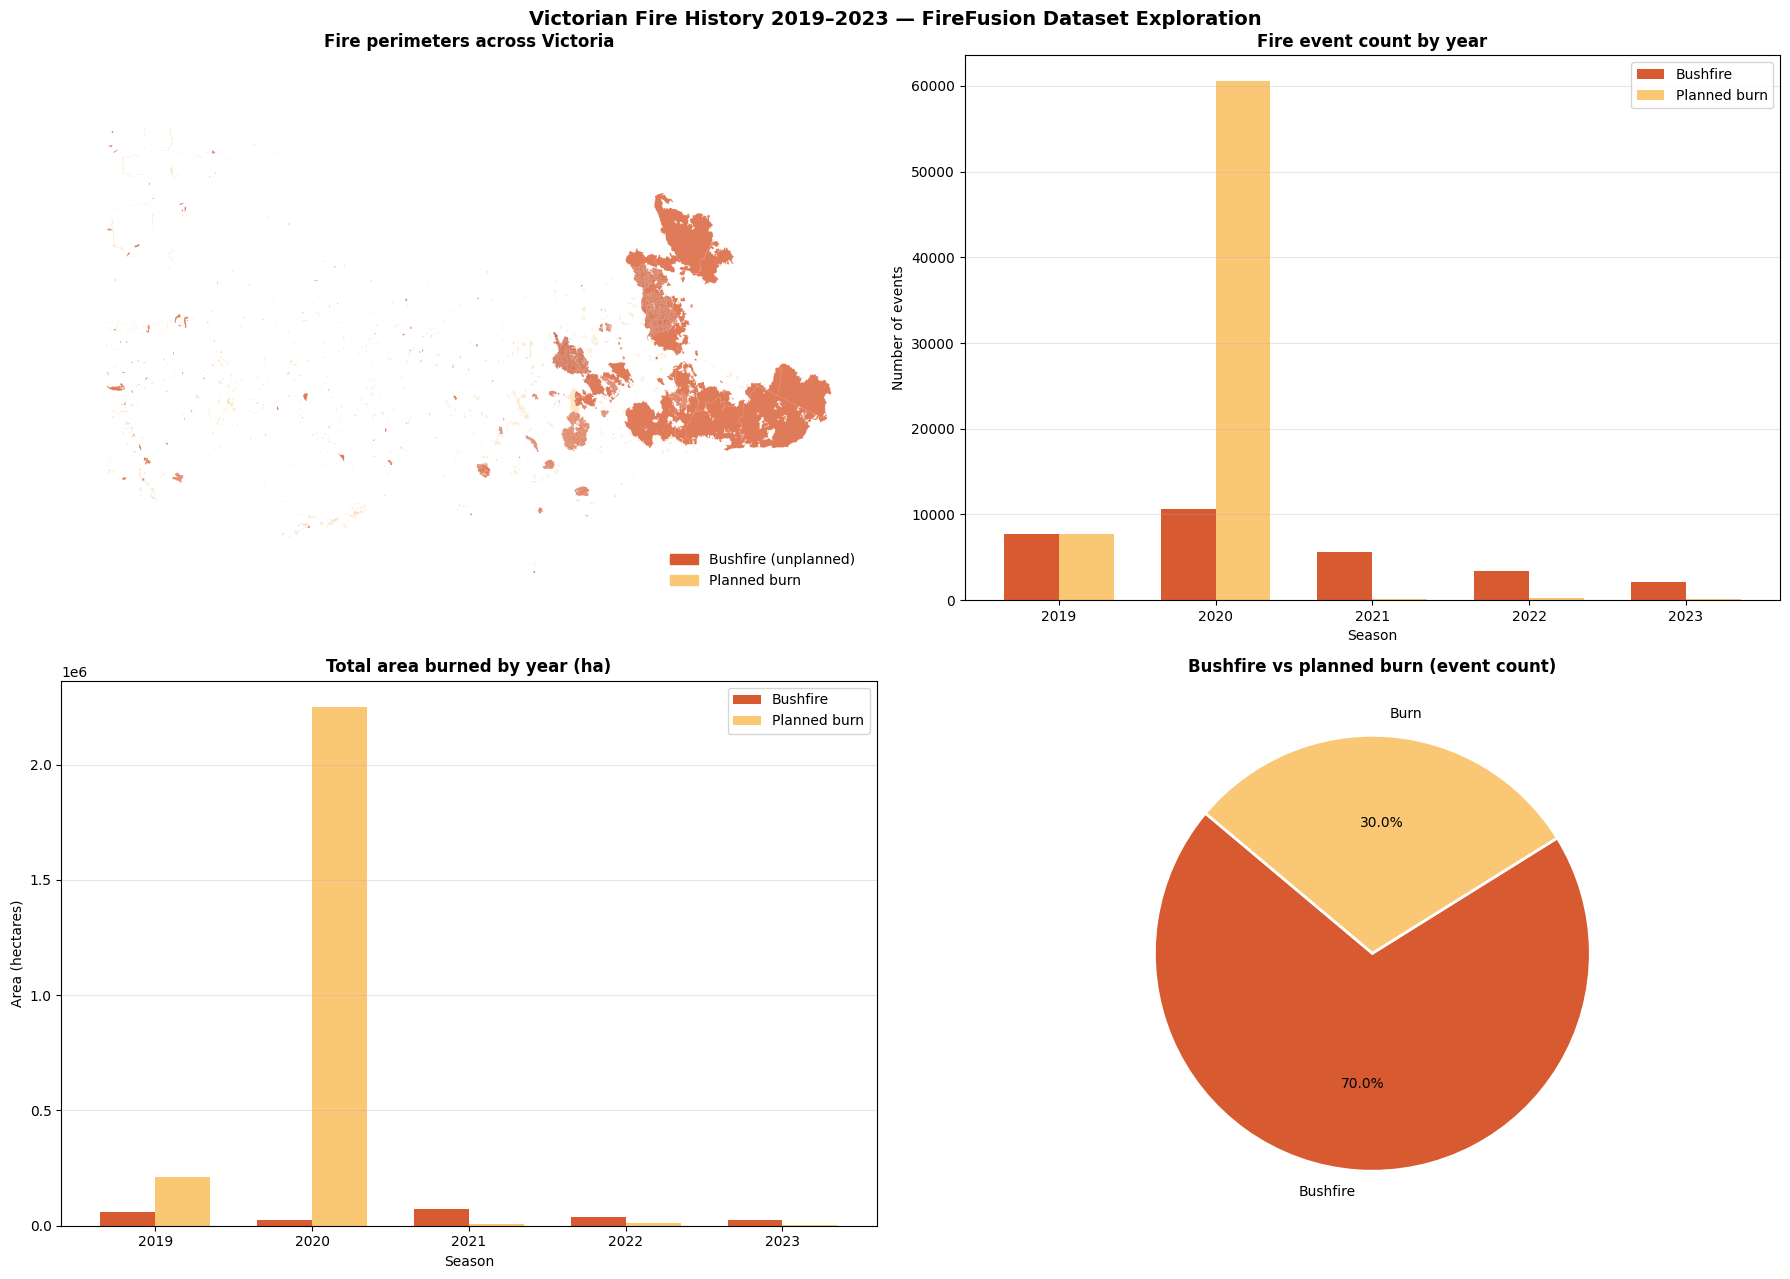

Saved → ../../src/data/firefusion_eda.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle("Victorian Fire History 2019–2023 — FireFusion Dataset Exploration",
             fontsize=14, fontweight="bold")

# ── 1. Map: fire perimeters ────────────────────────────────────────────────
ax = axes[0, 0]
proj = combined.to_crs(epsg=3857)
proj[proj["firetype"] == "Burn"].plot(ax=ax, color=C_BURN, edgecolor="none", alpha=0.4)
proj[proj["firetype"] == "Bushfire"].plot(ax=ax, color=C_BUSHFIRE, edgecolor="none", alpha=0.8)
ax.set_title("Fire perimeters across Victoria", fontweight="bold")
ax.axis("off")
ax.legend(handles=[
    mpatches.Patch(color=C_BUSHFIRE, label="Bushfire (unplanned)"),
    mpatches.Patch(color=C_BURN,     label="Planned burn"),
], loc="lower right", frameon=False)

# ── 2. Bar: event count by year & type ────────────────────────────────────
ax = axes[0, 1]
(combined.groupby(["season", "firetype"]).size()
         .unstack(fill_value=0)
         .plot(kind="bar", ax=ax, color=[C_BUSHFIRE, C_BURN], edgecolor="none", width=0.7))
ax.set_title("Fire event count by year", fontweight="bold")
ax.set_xlabel("Season"); ax.set_ylabel("Number of events")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Bushfire", "Planned burn"]); ax.grid(axis="y", alpha=0.3)

# ── 3. Bar: total area by year & type ─────────────────────────────────────
ax = axes[1, 0]
(combined.groupby(["season", "firetype"])["area_ha"].sum()
         .unstack(fill_value=0)
         .plot(kind="bar", ax=ax, color=[C_BUSHFIRE, C_BURN], edgecolor="none", width=0.7))
ax.set_title("Total area burned by year (ha)", fontweight="bold")
ax.set_xlabel("Season"); ax.set_ylabel("Area (hectares)")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Bushfire", "Planned burn"]); ax.grid(axis="y", alpha=0.3)

# ── 4. Pie: bushfire vs burn split ────────────────────────────────────────
ax = axes[1, 1]
counts = combined["firetype"].value_counts()
ax.pie(counts, labels=counts.index, autopct="%1.1f%%",
       colors=[C_BUSHFIRE, C_BURN], startangle=140,
       wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Bushfire vs planned burn (event count)", fontweight="bold")

plt.tight_layout()
plt.savefig("../../src/data/firefusion_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../../src/data/firefusion_eda.png")

/var/folders/k_/xq_dwbsn2pg2xl1z2xg8cpr40000gn/T/ipykernel_59811/2003675361.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="fire_severity", y="area_ha", data=sev_data, palette="YlOrRd", ax=ax)


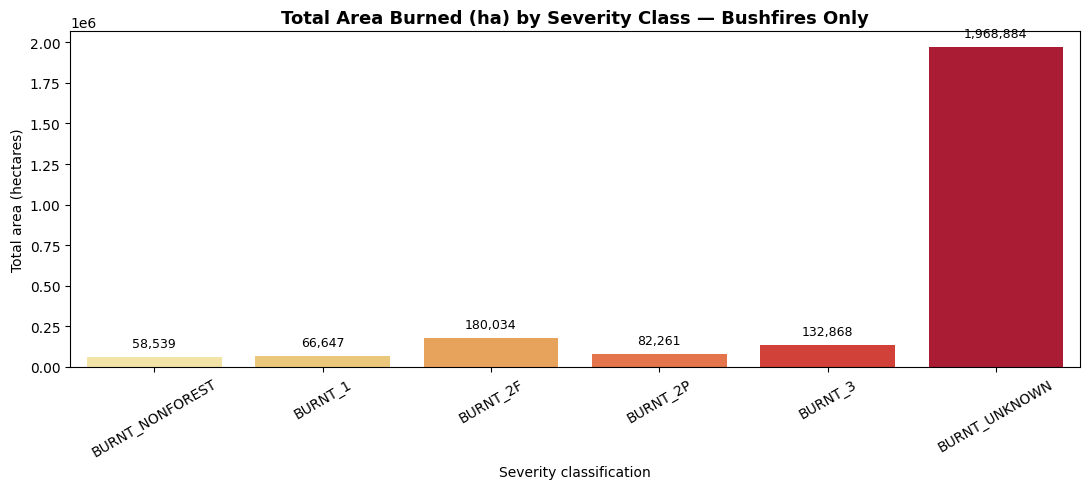

Saved → ../../src/data/firefusion_severity.png


In [6]:
# ── Severity analysis (bushfires only) ────────────────────────────────────
severity_order = ["BURNT_NONFOREST", "BURNT_1", "BURNT_2F", "BURNT_2P", "BURNT_3", "BURNT_UNKNOWN"]
sev_data = (
    bushfires.groupby("fire_severity")["area_ha"]
             .sum()
             .reindex(severity_order)
             .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x="fire_severity", y="area_ha", data=sev_data, palette="YlOrRd", ax=ax)
ax.set_title("Total Area Burned (ha) by Severity Class — Bushfires Only",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Severity classification")
ax.set_ylabel("Total area (hectares)")
plt.xticks(rotation=30)
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9, xytext=(0, 5),
                textcoords="offset points")
plt.tight_layout()
plt.savefig("../../src/data/firefusion_severity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../../src/data/firefusion_severity.png")